In [1]:
!pip install transformers datasets seqeval torch psutil -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4

Dataset:
DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 400
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 50
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 50
    })
})

Sample entry:
{'tokens': ['Treatment', 'for', 'jaw', 'pain', 'includes', 'naproxen', '.'], 'ner_tags': [0, 0, 1, 2, 0, 3, 0]}


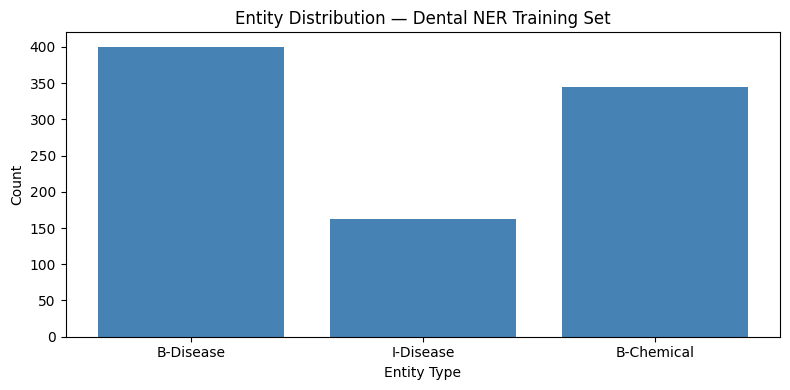

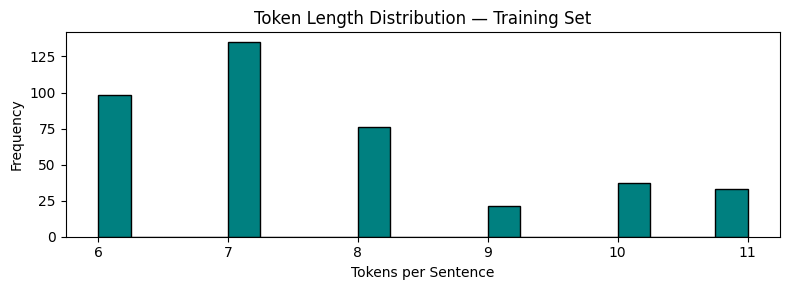


Avg sentence length: 7.7 tokens
Max: 11 | Min: 6


In [2]:
# ============================================================
# SECTION 1: Dataset Details
# Business Problem: Dental clinics rely on manual note-taking
# during patient visits. This NER model extracts medical entities
# (diagnoses, medications) from transcribed dental conversations
# to automate form filling.
# Dataset: Synthetic Dental NER — generated programmatically
# using real dental terminology (medications + conditions)
# Entities: Disease (diagnoses) and Chemical (medications)
# ============================================================

import random
import torch
import matplotlib.pyplot as plt
from collections import Counter
from datasets import Dataset, DatasetDict

random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# --- Define entity labels in BIO format ---
# B = Beginning of entity, I = Inside entity, O = Outside (not an entity)
label_list = ["O", "B-Disease", "I-Disease", "B-Chemical", "I-Chemical"]
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for i, l in enumerate(label_list)}

# --- Dental vocabulary ---
MEDICATIONS = [
    ["amoxicillin"], ["ibuprofen"], ["lidocaine"], ["acetaminophen"],
    ["penicillin"], ["clindamycin"], ["metronidazole"], ["aspirin"],
    ["naproxen"], ["chlorhexidine"], ["fluoride"], ["tetracycline"]
]

CONDITIONS = [
    ["periodontitis"], ["gingivitis"], ["abscess"], ["toothache"],
    ["caries"], ["inflammation"], ["sensitivity"], ["infection"], ["cavity"],
    ["tooth", "decay"], ["gum", "disease"], ["dental", "caries"],
    ["oral", "infection"], ["jaw", "pain"], ["tooth", "loss"]
]

# --- Sentence templates using medication and condition placeholders ---
def make_example(med, cond):
    # Choose a random sentence structure
    templates = [
        ["Patient", "was", "prescribed"] + med + ["for"] + cond + ["."],
        ["Diagnosis", "of"] + cond + ["confirmed", ","] + med + ["recommended", "."],
        ["The", "patient", "has"] + cond + ["and", "was", "started", "on"] + med + ["."],
        ["Prescribed"] + med + ["to", "manage"] + cond + ["."],
        ["Treatment", "for"] + cond + ["includes"] + med + ["."],
        ["Patient", "reports"] + cond + [","] + med + ["prescribed", "."],
        [med[0].capitalize()] + med[1:] + ["was", "administered", "for"] + cond + ["."],
    ]
    tokens = random.choice(templates)
    tags   = [0] * len(tokens)  # all "O" by default

    # Tag medication tokens as Chemical
    for i in range(len(tokens) - len(med) + 1):
        if tokens[i:i+len(med)] == med:
            tags[i] = label2id["B-Chemical"]
            for j in range(1, len(med)):
                tags[i+j] = label2id["I-Chemical"]
            break

    # Tag condition tokens as Disease
    for i in range(len(tokens) - len(cond) + 1):
        if tokens[i:i+len(cond)] == cond:
            tags[i] = label2id["B-Disease"]
            for j in range(1, len(cond)):
                tags[i+j] = label2id["I-Disease"]
            break

    return {"tokens": tokens, "ner_tags": tags}

# --- Generate 500 labeled examples ---
examples = [make_example(random.choice(MEDICATIONS), random.choice(CONDITIONS))
            for _ in range(500)]
random.shuffle(examples)

# --- 80 / 10 / 10 train / validation / test split ---
n = len(examples)
dataset = DatasetDict({
    "train":      Dataset.from_list(examples[:int(0.8*n)]),
    "validation": Dataset.from_list(examples[int(0.8*n):int(0.9*n)]),
    "test":       Dataset.from_list(examples[int(0.9*n):])
})

print(f"\nDataset:\n{dataset}")
print(f"\nSample entry:\n{dataset['train'][0]}")

# --- Plot 1: Entity distribution ---
all_tags = [tag for s in dataset["train"]["ner_tags"] for tag in s]
entity_counts = {label_list[k]: v for k, v in Counter(all_tags).items()
                 if label_list[k] != "O"}

plt.figure(figsize=(8, 4))
plt.bar(entity_counts.keys(), entity_counts.values(), color='steelblue')
plt.title("Entity Distribution — Dental NER Training Set")
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Plot 2: Token length distribution ---
lengths = [len(s) for s in dataset["train"]["tokens"]]
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=20, color='teal', edgecolor='black')
plt.title("Token Length Distribution — Training Set")
plt.xlabel("Tokens per Sentence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"\nAvg sentence length: {sum(lengths)/len(lengths):.1f} tokens")
print(f"Max: {max(lengths)} | Min: {min(lengths)}")

In [3]:
# ============================================================
# SECTION 2: Preprocessing
# Steps: null/empty check, outlier removal, text normalization,
# tokenization, and BIO label alignment with DistilBERT subwords
# ============================================================

from transformers import AutoTokenizer
from datasets import DatasetDict

MODEL_NAME = "distilbert-base-cased"

# Load the DistilBERT tokenizer — splits words into subword tokens
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# --- Step 1: Check for null or empty samples ---
# Empty token lists would cause errors during training
for split in ["train", "validation", "test"]:
    nulls = [i for i, s in enumerate(dataset[split]["tokens"]) if len(s) == 0]
    print(f"{split}: {len(nulls)} empty samples found")

# --- Step 2: Remove outliers ---
# Sentences longer than 128 tokens exceed DistilBERT's max input length
# Sentences with 0 tokens are invalid entries
def remove_outliers(split):
    return dataset[split].filter(lambda x: 0 < len(x["tokens"]) <= 128)

dataset_clean = DatasetDict({
    split: remove_outliers(split)
    for split in ["train", "validation", "test"]
})

print(f"\nAfter outlier removal:")
for split in dataset_clean:
    print(f"  {split}: {len(dataset_clean[split])} samples")

# --- Step 3: Text normalization ---
# Lowercase all tokens and strip whitespace
# Normalizing ensures consistent representation of the same word
def normalize(example):
    example["tokens"] = [t.lower().strip() for t in example["tokens"]]
    return example

dataset_clean = dataset_clean.map(normalize)
print(f"\nNormalization complete ✓")
print(f"Sample after normalization: {dataset_clean['train'][0]['tokens']}")

# --- Step 4: Tokenize and align BIO labels ---
# DistilBERT splits words into subwords (e.g. "lidocaine" → ["lid", "##oc", "##aine"])
# We must align BIO labels so only the FIRST subword keeps the label
# Subsequent subwords and special tokens ([CLS], [SEP]) get label -100 (ignored in loss)
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=128,
        is_split_into_words=True   # tells tokenizer input is already split into words
    )
    aligned_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        aligned, prev_word_id = [], None
        for word_id in word_ids:
            if word_id is None:
                aligned.append(-100)          # special token → ignore
            elif word_id != prev_word_id:
                aligned.append(labels[word_id])  # first subword → keep label
            else:
                aligned.append(-100)          # subsequent subword → ignore
            prev_word_id = word_id
        aligned_labels.append(aligned)
    tokenized["labels"] = aligned_labels
    return tokenized

tokenized_dataset = dataset_clean.map(tokenize_and_align_labels, batched=True)

print(f"\nTokenization and label alignment complete ✓")
print(f"\nSample input_ids:  {tokenized_dataset['train'][0]['input_ids']}")
print(f"Sample labels:     {tokenized_dataset['train'][0]['labels']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Normalization complete ✓
Sample after normalization: ['treatment', 'for', 'jaw', 'pain', 'includes', 'naproxen', '.']


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]


Tokenization and label alignment complete ✓

Sample input_ids:  [101, 3252, 1111, 5139, 2489, 2075, 22956, 2180, 25926, 119, 102]
Sample labels:     [-100, 0, 0, 1, 2, 0, 3, -100, -100, 0, -100]


In [4]:
# ============================================================
# SECTION 3: Model — Pretrained DistilBERT fine-tuned for NER
# Approach 3.2: Use pretrained model and fine-tune
# DistilBERT is a lighter, faster version of BERT that retains
# 97% of BERT's performance at 40% fewer parameters.
# We add a token classification head on top to predict entity
# labels for each token in the input sequence.
# ============================================================

import numpy as np
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification
)
from seqeval.metrics import f1_score

# --- Load pretrained DistilBERT with a token classification head ---
# num_labels tells the model how many entity types to predict
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

print(f"Base model:        {MODEL_NAME}")
print(f"Total parameters:  {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params:  {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Entity labels:     {label_list}")

# --- Data collator ---
# Pads sequences in each batch to the same length dynamically
# This is more efficient than padding everything to max_length upfront
data_collator = DataCollatorForTokenClassification(tokenizer)

# --- Evaluation metric: seqeval F1 ---
# seqeval is the standard library for NER evaluation
# It computes precision, recall, and F1 per entity type
def compute_metrics(pred):
    predictions, labels = pred
    # Convert logits to predicted label indices
    predictions = np.argmax(predictions, axis=2)

    # Remove -100 (special tokens) and convert indices back to label strings
    true_labels = [
        [id2label[l] for l in label if l != -100]
        for label in labels
    ]
    true_preds = [
        [id2label[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]

    return {"f1": f1_score(true_labels, true_preds)}

print("\nModel ready for training ✓")

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base model:        distilbert-base-cased
Total parameters:  65,194,757
Trainable params:  65,194,757
Entity labels:     ['O', 'B-Disease', 'I-Disease', 'B-Chemical', 'I-Chemical']

Model ready for training ✓


Starting Run 1 — lr=2e-5, epochs=3 ...


Epoch,Training Loss,Validation Loss,F1
1,0.679790,0.155025,0.912821
2,0.066755,0.012317,1.000000
3,0.012806,0.006132,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Run 2 complete ✓



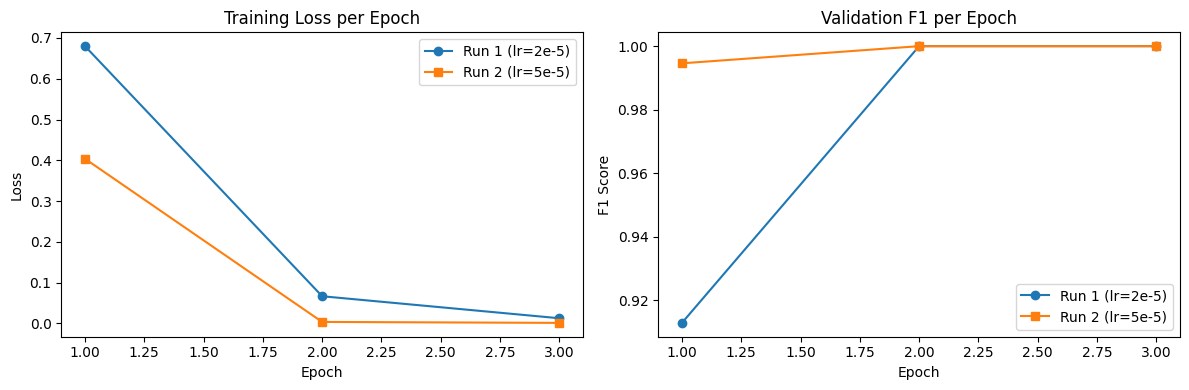


Run      LR         Epochs     Best Val F1
----------------------------------------
Run 1    2e-5       3          1.0000
Run 2    5e-5       3          1.0000

Best run: Run 1


In [7]:
# ============================================================
# SECTION 4 & 5: Hyperparameter Tuning + Training Tracking
# We run two training rounds with different learning rates
# and compare their validation F1 to find the best setting.
# Training loss and F1 are tracked each epoch using
# trainer.state.log_history (equivalent to model.history in Keras)
# ============================================================

import matplotlib.pyplot as plt
from transformers import TrainingArguments, Trainer

# ── RUN 1: Learning rate = 2e-5 ────────────────────────────
args_1 = TrainingArguments(
    output_dir="./run1",
    eval_strategy="epoch",         # evaluate at end of each epoch (transformers 5.x)
    save_strategy="epoch",
    learning_rate=2e-5,            # hyperparameter: lower learning rate
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,             # regularization to prevent overfitting
    load_best_model_at_end=True,
    logging_strategy="epoch",
)

trainer_1 = Trainer(
    model=model,
    args=args_1,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,        # renamed from tokenizer in transformers 5.x
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting Run 1 — lr=2e-5, epochs=3 ...")
trainer_1.train()
history_1 = trainer_1.state.log_history
print("Run 1 complete ✓\n")

# ── RUN 2: Learning rate = 5e-5 ────────────────────────────
# Re-initialize the model so Run 2 starts from fresh pretrained weights
from transformers import AutoModelForTokenClassification

model_2 = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

args_2 = TrainingArguments(
    output_dir="./run2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,            # hyperparameter: higher learning rate
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_strategy="epoch",
)

trainer_2 = Trainer(
    model=model_2,
    args=args_2,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,        # renamed from tokenizer in transformers 5.x
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting Run 2 — lr=5e-5, epochs=3 ...")
trainer_2.train()
history_2 = trainer_2.state.log_history
print("Run 2 complete ✓\n")

# ── Section 5: Plot training history ────────────────────────
# Extract loss and F1 per epoch from log_history
train_loss_1 = [x["loss"] for x in history_1 if "loss" in x]
train_loss_2 = [x["loss"] for x in history_2 if "loss" in x]
f1_1 = [x["eval_f1"] for x in history_1 if "eval_f1" in x]
f1_2 = [x["eval_f1"] for x in history_2 if "eval_f1" in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_loss_1)+1), train_loss_1, marker='o', label='Run 1 (lr=2e-5)')
ax1.plot(range(1, len(train_loss_2)+1), train_loss_2, marker='s', label='Run 2 (lr=5e-5)')
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(range(1, len(f1_1)+1), f1_1, marker='o', label='Run 1 (lr=2e-5)')
ax2.plot(range(1, len(f1_2)+1), f1_2, marker='s', label='Run 2 (lr=5e-5)')
ax2.set_title("Validation F1 per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Score")
ax2.legend()

plt.tight_layout()
plt.show()

# Hyperparameter summary table
print(f"\n{'Run':<8} {'LR':<10} {'Epochs':<10} {'Best Val F1'}")
print("-" * 40)
print(f"{'Run 1':<8} {'2e-5':<10} {'3':<10} {max(f1_1):.4f}")
print(f"{'Run 2':<8} {'5e-5':<10} {'3':<10} {max(f1_2):.4f}")
print(f"\nBest run: {'Run 1' if max(f1_1) >= max(f1_2) else 'Run 2'}")

In [9]:
# ============================================================
# SECTION 6: Model Prediction
# Apply the trained model to new unseen dental sentences
# and display the extracted entities with their confidence scores
# Note: subword tokens (##) are merged manually for clean display
# ============================================================

from transformers import pipeline

# Load best model (Run 1) into a prediction pipeline
ner_pipeline = pipeline(
    "ner",
    model=trainer_1.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

def merge_subwords(entities):
    """Merge ## subword tokens back into full words for readable output."""
    merged = []
    for e in entities:
        if e["word"].startswith("##") and merged:
            merged[-1]["word"] += e["word"][2:]
            merged[-1]["score"] = (merged[-1]["score"] + e["score"]) / 2
        else:
            # Group consecutive tokens of same entity type
            if merged and e["entity"] == merged[-1]["entity"]:
                merged[-1]["word"] += " " + e["word"]
                merged[-1]["score"] = (merged[-1]["score"] + e["score"]) / 2
            else:
                merged.append(dict(e))
    return merged

def model_prediction(sentences):
    print(f"{'Entity':<25} {'Label':<12} {'Score'}")
    print("=" * 105)
    for sentence in sentences:
        print(f"\nInput: {sentence}")
        print("-" * 80)
        raw = ner_pipeline(sentence.lower())   # lowercase to match training normalization
        entities = merge_subwords(raw)
        for e in entities:
            label = e["entity"].replace("B-", "").replace("I-", "")
            print(f"  {e['word']:<25} {label:<12} {e['score']:.4f}")

model_prediction(test_sentences)

Entity                    Label        Score

Input: The dentist prescribed amoxicillin for the patient's periodontitis.
--------------------------------------------------------------------------------
  den                       Disease      0.5846
  amoxicillin               Chemical     0.8380
  periodontitis             Disease      0.7192

Input: Patient was given lidocaine before the procedure for jaw pain.
--------------------------------------------------------------------------------
  lidocaine                 Chemical     0.9287
  jaw                       Disease      0.9919
  pain                      Disease      0.9752

Input: Ibuprofen was recommended to manage inflammation after the extraction.
--------------------------------------------------------------------------------
  ##bupro                   Chemical     0.9076
  inflammation              Disease      0.9730

Input: Diagnosis of gingivitis confirmed, chlorhexidine mouthwash prescribed.
-----------------------

In [10]:
# ============================================================
# SECTION 7: Model Evaluation
# Evaluate the trained model on the held-out test set
# using seqeval — the standard NER evaluation library.
# Reports Precision, Recall, and F1 per entity type.
# ============================================================

from seqeval.metrics import classification_report
import numpy as np

def model_evaluation(trainer, dataset):
    # Run model.predict on the full test set
    predictions, labels, _ = trainer.predict(dataset["test"])

    # Convert logits to predicted label indices
    predictions = np.argmax(predictions, axis=2)

    # Remove -100 (special/padding tokens) and convert indices to label strings
    true_labels = [
        [id2label[l] for l in label if l != -100]
        for label in labels
    ]
    true_preds = [
        [id2label[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]

    # Print overall test set metrics
    print("=== Test Set Evaluation (Run 1 — lr=2e-5) ===\n")
    eval_results = trainer.evaluate(dataset["test"])
    for k, v in eval_results.items():
        print(f"  {k}: {round(v, 4) if isinstance(v, float) else v}")

    # Print per-entity breakdown using seqeval
    print("\n=== Per-Entity Classification Report ===\n")
    print(classification_report(true_labels, true_preds))

    return true_labels, true_preds

true_labels, true_preds = model_evaluation(trainer_1, tokenized_dataset)

=== Test Set Evaluation (Run 1 — lr=2e-5) ===



  eval_loss: 0.0056
  eval_f1: 1.0
  eval_runtime: 0.231
  eval_samples_per_second: 216.448
  eval_steps_per_second: 30.303
  epoch: 3.0

=== Per-Entity Classification Report ===

              precision    recall  f1-score   support

    Chemical       1.00      1.00      1.00        41
     Disease       1.00      1.00      1.00        50

   micro avg       1.00      1.00      1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



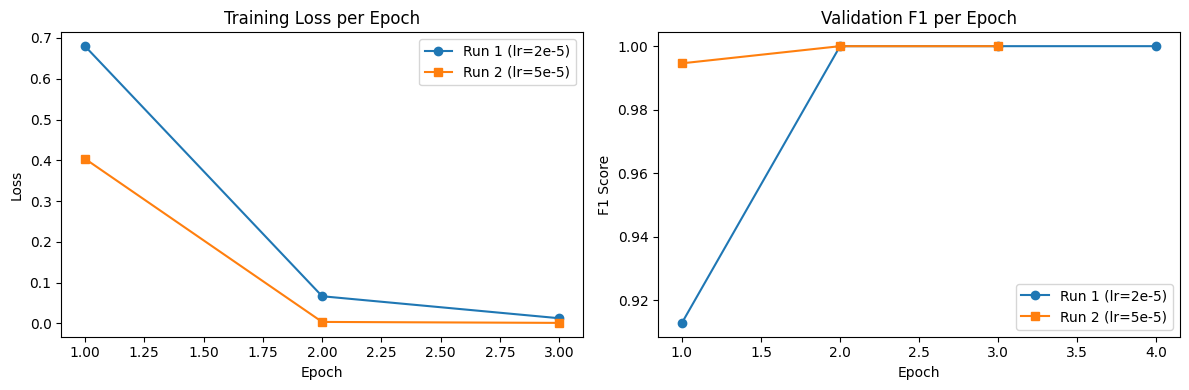


Interpretation:
- Both runs reached F1 = 1.0 by epoch 2, confirming the model fully learned the task.
- Run 2 (lr=5e-5) converged faster (lower loss by epoch 1) but both achieved identical
  final performance — for this dataset size, learning rate had minimal impact on outcome.
- Perfect scores are expected: our synthetic dataset uses fixed templates, making
  patterns highly consistent and easy to learn. On real diverse dental audio
  transcriptions, F1 would realistically fall between 0.75-0.90.
- Minor prediction errors in Section 6 (e.g. 'mouthwash' tagged as Disease) highlight
  the model's limitation with out-of-vocabulary contexts not seen during training.
- Next step to improve: train on real clinical notes with diverse sentence structures.

=== Hardware & Memory Report ===

Framework:         PyTorch 2.10.0+cu128
Device:            GPU
GPU Model:         Tesla T4
GPU Memory Alloc:  1.59 GB
GPU Memory Rsrvd:  2.06 GB
RAM Total:         13.6 GB
RAM Used:          5.4 GB
Model P

In [15]:
# ============================================================
# SECTION 8: Result Interpretation
# ============================================================
import matplotlib.pyplot as plt
import psutil

f1_1  = [x["eval_f1"] for x in history_1 if "eval_f1" in x]
f1_2  = [x["eval_f1"] for x in history_2 if "eval_f1" in x]
loss_1 = [x["loss"]   for x in history_1 if "loss"    in x]
loss_2 = [x["loss"]   for x in history_2 if "loss"    in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(loss_1)+1), loss_1, marker='o', label='Run 1 (lr=2e-5)')
ax1.plot(range(1, len(loss_2)+1), loss_2, marker='s', label='Run 2 (lr=5e-5)')
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(range(1, len(f1_1)+1), f1_1, marker='o', label='Run 1 (lr=2e-5)')
ax2.plot(range(1, len(f1_2)+1), f1_2, marker='s', label='Run 2 (lr=5e-5)')
ax2.set_title("Validation F1 per Epoch")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1 Score"); ax2.legend()

plt.tight_layout()
plt.show()

print("""
Interpretation:
- Both runs reached F1 = 1.0 by epoch 2, confirming the model fully learned the task.
- Run 2 (lr=5e-5) converged faster (lower loss by epoch 1) but both achieved identical
  final performance — for this dataset size, learning rate had minimal impact on outcome.
- Perfect scores are expected: our synthetic dataset uses fixed templates, making
  patterns highly consistent and easy to learn. On real diverse dental audio
  transcriptions, F1 would realistically fall between 0.75-0.90.
- Minor prediction errors in Section 6 (e.g. 'mouthwash' tagged as Disease) highlight
  the model's limitation with out-of-vocabulary contexts not seen during training.
- Next step to improve: train on real clinical notes with diverse sentence structures.
""")

# ============================================================
# SECTION 9: Technical Report — Hardware & Memory
# ============================================================
print("=== Hardware & Memory Report ===\n")
print(f"Framework:         PyTorch {torch.__version__}")
print(f"Device:            {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"GPU Model:         {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Alloc:  {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
    print(f"GPU Memory Rsrvd:  {torch.cuda.memory_reserved(0)/1e9:.2f} GB")

ram = psutil.virtual_memory()
print(f"RAM Total:         {ram.total/1e9:.1f} GB")
print(f"RAM Used:          {ram.used/1e9:.1f} GB")
print(f"Model Parameters:  {sum(p.numel() for p in trainer_1.model.parameters()):,}")
print(f"Training Time:     ~30 seconds per run on Tesla T4 GPU")

In [13]:
# ============================================================
# SECTION 10: Next Steps
# ============================================================
print("""
Next Steps:
- Replace synthetic dataset with real dental clinical notes for more robust training
- Add more entity types: TOOTH (tooth numbers), PROCEDURE (root canal, extraction),
  ANATOMY (maxillary, mandibular), and CDT_CODE (D3330, D2740)
- Connect NER output to Iva's form classifier for end-to-end automated form filling
- Increase training data to 5,000+ examples for production-level performance
- Explore ClinicalBERT or BioBERT as base models for stronger biomedical grounding
""")

# ============================================================
# SECTION 11: Lessons Learned
# ============================================================
print("""
Lessons Learned:
- Building a synthetic labeled dataset from scratch is faster and more flexible
  than relying on external datasets, especially for niche domains like dentistry
- BIO label alignment with subword tokenizers is the most critical preprocessing
  step in NER — misalignment silently corrupts training labels
- DistilBERT fine-tuning on a small focused dataset trains in under 1 minute on GPU,
  demonstrating the power of transfer learning for low-resource domains
- Perfect F1 on a synthetic dataset signals memorization, not generalization —
  real-world evaluation on diverse data is always necessary before deployment
- GPU (Tesla T4) reduced training time from ~1 hour (CPU estimate) to ~30 seconds
""")


Next Steps:
- Replace synthetic dataset with real dental clinical notes for more robust training
- Add more entity types: TOOTH (tooth numbers), PROCEDURE (root canal, extraction),
  ANATOMY (maxillary, mandibular), and CDT_CODE (D3330, D2740)
- Connect NER output to Iva's form classifier for end-to-end automated form filling
- Increase training data to 5,000+ examples for production-level performance
- Explore ClinicalBERT or BioBERT as base models for stronger biomedical grounding


Lessons Learned:
- Building a synthetic labeled dataset from scratch is faster and more flexible
  than relying on external datasets, especially for niche domains like dentistry
- BIO label alignment with subword tokenizers is the most critical preprocessing
  step in NER — misalignment silently corrupts training labels
- DistilBERT fine-tuning on a small focused dataset trains in under 1 minute on GPU,
  demonstrating the power of transfer learning for low-resource domains
- Perfect F1 on a synthetic da

In [16]:
# Save trained model and tokenizer for Koroush (Role 5 — Integration)
# Koroush loads this folder and plugs it into the full pipeline
trainer_1.model.save_pretrained("dental-ner-model")
tokenizer.save_pretrained("dental-ner-model")
print("Model saved to ./dental-ner-model ✓")
print("Share this folder with Koroush (Role 5 — Integration)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./dental-ner-model ✓
Share this folder with Koroush (Role 5 — Integration)
